In [47]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

**Load the dataset**

**part 1: File I/O with Pandas**

In [48]:
import pandas as pd
df = pd.read_csv("Reviews.csv", nrows=5000)
print(df.shape)

(5000, 10)


In [49]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Id                      5000 non-null   int64 
 1   ProductId               5000 non-null   object
 2   UserId                  5000 non-null   object
 3   ProfileName             5000 non-null   object
 4   HelpfulnessNumerator    5000 non-null   int64 
 5   HelpfulnessDenominator  5000 non-null   int64 
 6   Score                   5000 non-null   int64 
 7   Time                    5000 non-null   int64 
 8   Summary                 5000 non-null   object
 9   Text                    5000 non-null   object
dtypes: int64(5), object(5)
memory usage: 390.8+ KB


**PART 2: DataFrame Operations**

**Indexing**

In [51]:
df['Text'].head()
df[['Text', 'Score']].head()

,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1
2,This is a confection that has been around a fe...,4
3,If you are looking for the secret ingredient i...,2
4,Great taffy at a great price. There was a wid...,5


**Filtering**

In [52]:
positive_df = df[df['Score'] >= 4]
negative_df = df[df['Score'] <= 2]

**Sorting**

In [53]:
df_sorted = df.sort_values(by='Score', ascending=False)

**Grouping**

In [54]:
df.groupby('Score')['Text'].count()

,Text
Score,
1,469
2,290
3,395
4,712
5,3134


**Create New Column**

In [55]:
df['text_length'] = df['Text'].apply(len)

In [56]:
df['text_length']

,text_length
0,263
1,190
2,509
3,219
4,140
...,...
4995,578
4996,682
4997,552
4998,689


**String operations**

In [57]:
df['Text_lower'] = df['Text'].str.lower()

**PART 3: Descriptive Statistics**

In [58]:
df.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,text_length
count,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000
mean,2500.500000,1.580200,2.067200,4.150400,1.294930e+09,409.082400
std,1443.520003,5.584533,6.288672,1.326549,4.802063e+07,407.469053
min,1.000000,0.000000,0.000000,1.000000,9.617184e+08,57.000000
25%,1250.750000,0.000000,0.000000,4.000000,1.271376e+09,177.000000
50%,2500.500000,0.000000,1.000000,5.000000,1.309219e+09,289.500000
75%,3750.250000,2.000000,2.000000,5.000000,1.330301e+09,489.000000
max,5000.000000,187.000000,216.000000,5.000000,1.351210e+09,5276.000000


In [59]:
df['word_count'] = df['Text'].apply(lambda x: len(x.split()))

In [60]:
df['word_count']

,word_count
0,48
1,31
2,94
3,41
4,27
...,...
4995,105
4996,121
4997,105
4998,120


In [61]:
# Character count
df['char_count'] = df['Text'].apply(len)

In [62]:
# Average text length
print("Average words:", df['word_count'].mean())

Average words: 75.1188


In [63]:
# Vocabulary size
all_words = " ".join(df['Text']).split()
vocab = set(all_words)
print("Vocabulary size:", len(vocab))

Vocabulary size: 33142


In [64]:
# Top frequent words

common_words = Counter(all_words).most_common(10)
print(common_words)

[('the', 13559), ('I', 11728), ('and', 10541), ('a', 9370), ('to', 8026), ('of', 6272), ('is', 5615), ('it', 4955), ('for', 4330), ('this', 4024)]


In [65]:
# Missing percentage
missing = df['Text'].isnull().mean() * 100
print("Missing %:", missing)

Missing %: 0.0


**PART 4: Text Preprocessing**

In [66]:
# Setup tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [67]:
import re

def preprocess(text):
    text = text.lower()

    # remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # remove punctuation (keep words)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # normalize spaces
    text = " ".join(text.split())

    # remove stopwords (but keep "not")
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]

    return " ".join(tokens)

In [68]:
df['clean_text'] = df['Text'].apply(preprocess)

In [69]:
df.to_csv("cleaned_reviews.csv", index=False)

**PART 5: Data Visualization**

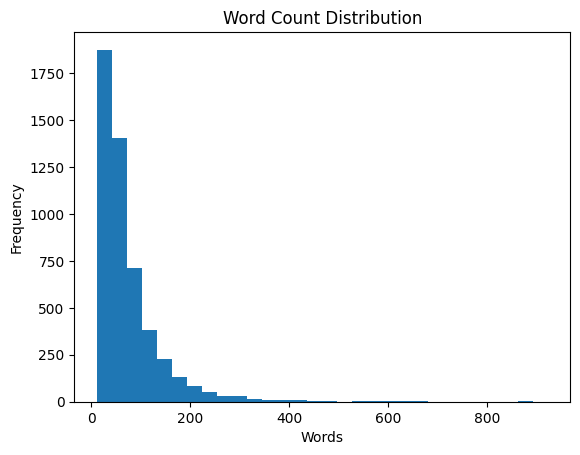

In [70]:
plt.hist(df['word_count'], bins=30)
plt.title("Word Count Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

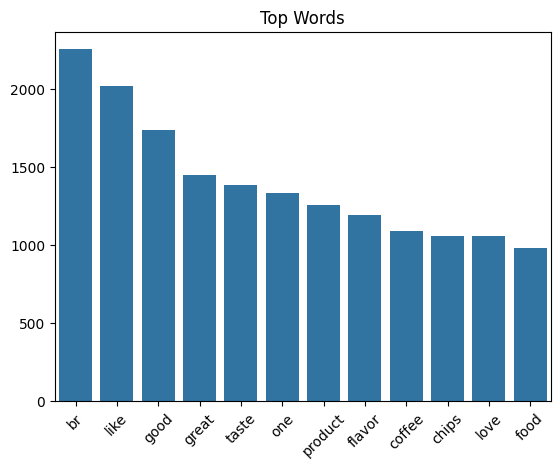

In [71]:
clean_words = " ".join(df['clean_text']).split()
top_words = Counter(clean_words).most_common(12)

words, counts = zip(*top_words)

sns.barplot(x=list(words), y=list(counts))
plt.xticks(rotation=45)
plt.title("Top Words")
plt.show()

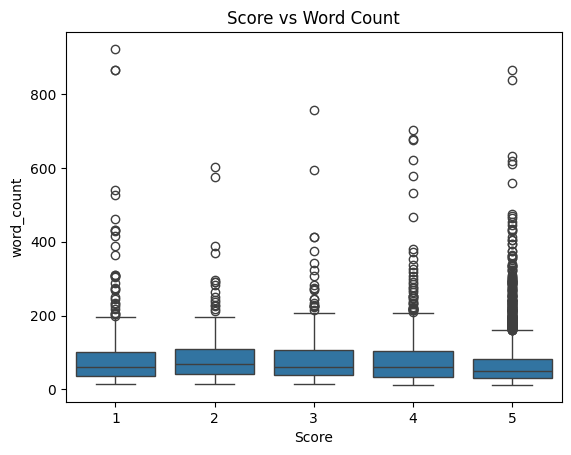

In [72]:
sns.boxplot(x='Score', y='word_count', data=df)
plt.title("Score vs Word Count")
plt.show()

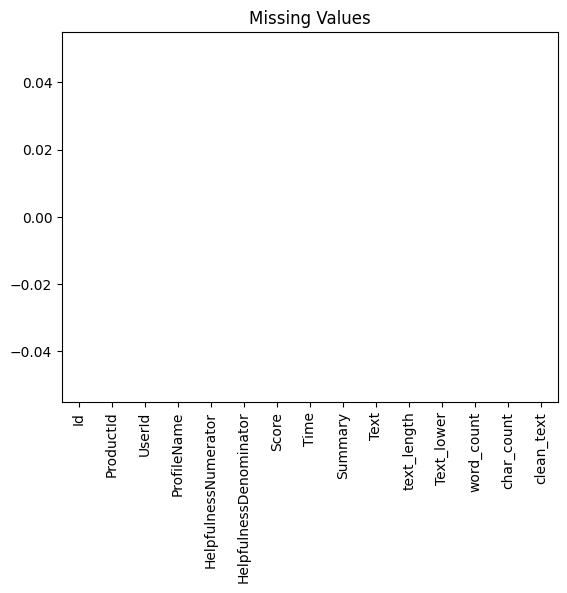

In [73]:
df.isnull().sum().plot(kind='bar')
plt.title("Missing Values")
plt.show()

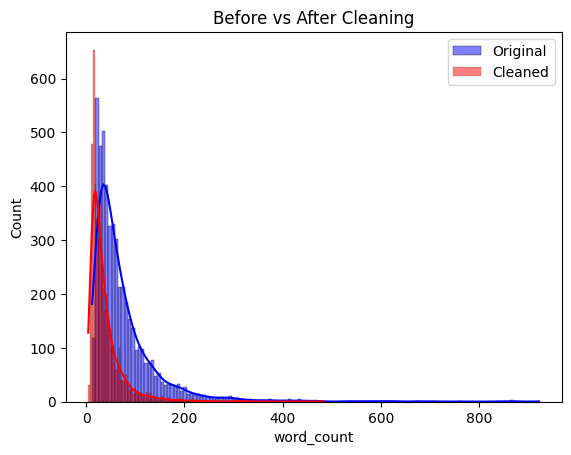

In [74]:
df['clean_length'] = df['clean_text'].apply(lambda x: len(x.split()))

sns.histplot(df['word_count'], color='blue', label='Original', kde=True)
sns.histplot(df['clean_length'], color='red', label='Cleaned', kde=True)

plt.legend()
plt.title("Before vs After Cleaning")
plt.show()

In [75]:
def get_sentiment(score):
    if score <= 2:
        return "negative"
    elif score == 3:
        return "neutral"
    else:
        return "positive"

df['sentiment'] = df['Score'].apply(get_sentiment)

In [76]:
df['avg_word_length'] = df['char_count'] / df['word_count']

df['stopword_count'] = df['Text'].apply(
    lambda x: len([w for w in x.lower().split() if w in stop_words])
)

df['uppercase_count'] = df['Text'].apply(
    lambda x: sum(1 for c in x if c.isupper())
)

In [77]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,2), max_features=10)
ngrams = vectorizer.fit_transform(df['clean_text'])

print(vectorizer.get_feature_names_out())

['dog food' 'gluten free' 'green tea' 'grocery store' 'highly recommend'
 'hot chocolate' 'hot cocoa' 'ive tried' 'much better' 'potato chips']


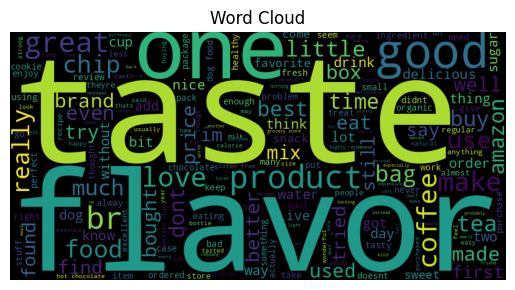

In [78]:
from wordcloud import WordCloud

text = " ".join(df['clean_text'])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud)
plt.axis('off')
plt.title("Word Cloud")
plt.show()

In [79]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=2000)

X = tfidf.fit_transform(df['clean_text'])

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

X_train, X_test, y_train, y_test = train_test_split(
    X, df['sentiment'], test_size=0.2, random_state=42
)

model = LinearSVC()
model.fit(X_train, y_train)

LinearSVC()

In [81]:
from sklearn.metrics import accuracy_score

preds = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.828


In [87]:
sample = "this product is terrible"

clean = preprocess(sample)
vec = tfidf.transform([clean])
pred = model.predict(vec)


print("Prediction:", pred[0])

Prediction: negative


In [88]:
import pickle

# save model
pickle.dump(model, open("models.pkl", "wb"))

# save tfidf
pickle.dump(tfidf, open("tfidfs.pkl", "wb"))

In [89]:
from google.colab import files

files.download("models.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [90]:
files.download("tfidfs.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>